# Pepper seed extraction and analyze the impurity
## Steps
<ol>
    <li>Image preprocessing</li>
    <li>Seed segmentation / Isolate a seed from an image</li>
    <li>Feature extraction of the isolated seed</li>
</ol>

In [28]:
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from skimage import color, img_as_ubyte
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
# Load the image
image_path = "C:\\Users\\PC\\Downloads\\IMG-20250210-WA0005.jpg"
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image not found or unable to load.")

In [30]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [31]:
# Apply GaussianBlur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

In [32]:
# Use Adaptive Histogram Equalization (CLAHE) for contrast enhancement
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_gray = clahe.apply(blurred)

In [33]:
# Apply Adaptive Thresholding for better segmentation
binary_image = cv2.adaptiveThreshold(
    enhanced_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2
)

In [34]:
# Perform Morphological Closing to fill small holes
kernel = np.ones((5,5), np.uint8)
closed = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    raise ValueError("No contours found. Adjust preprocessing steps.")

# Select the largest contour (assuming it's the pepper seed)
largest_contour = max(contours, key=cv2.contourArea)

# Create a mask for the largest contour
mask = np.zeros_like(gray)
cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

# Bitwise AND the mask with the original image to isolate the seed
isolated_seed = cv2.bitwise_and(image, image, mask=mask)

In [35]:
# Save and display the isolated seed
cv2.imwrite("isolated_seed.jpg", isolated_seed)
cv2.imshow('Original Image', image)
cv2.imshow('Isolated Seed', isolated_seed)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [36]:
### Extract Features ###
def extract_features(image_path):
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found or unable to load.")

    # Convert to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize the image (optional, for consistency)
    resized_image = cv2.resize(gray_image, (256, 256))

    # Noise reduction using Gaussian Blur
    blurred_image = cv2.GaussianBlur(resized_image, (5, 5), 0)

    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(blurred_image)

    # Convert to 8-bit unsigned integer for GLCM
    enhanced_image = img_as_ubyte(enhanced_image)

    # Compute Gray-Level Co-occurrence Matrix (GLCM) features
    glcm = graycomatrix(enhanced_image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]

    # Apply adaptive thresholding for better segmentation
    binary_image = cv2.adaptiveThreshold(
        enhanced_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )

    # Find contours again for feature extraction
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No contours found in feature extraction.")

    # Select the largest contour
    largest_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest_contour)  # Area of the largest contour
    perimeter = cv2.arcLength(largest_contour, True)  # Perimeter

    # Compute aspect ratio
    x, y, w, h = cv2.boundingRect(largest_contour)
    aspect_ratio = float(w) / h

    # Compute histogram
    histogram = cv2.calcHist([enhanced_image], [0], None, [256], [0, 256]).flatten()

    # Return extracted features
    features = {
        "histogram": histogram,
        "contrast": contrast,
        "energy": energy,
        "area": area,
        "perimeter": perimeter,
        "aspect_ratio": aspect_ratio
    }
    return features

In [37]:
# Extract features
features = extract_features("isolated_seed.jpg")

In [38]:
histogram = features["histogram"]
print("Color Histogram")

Color Histogram


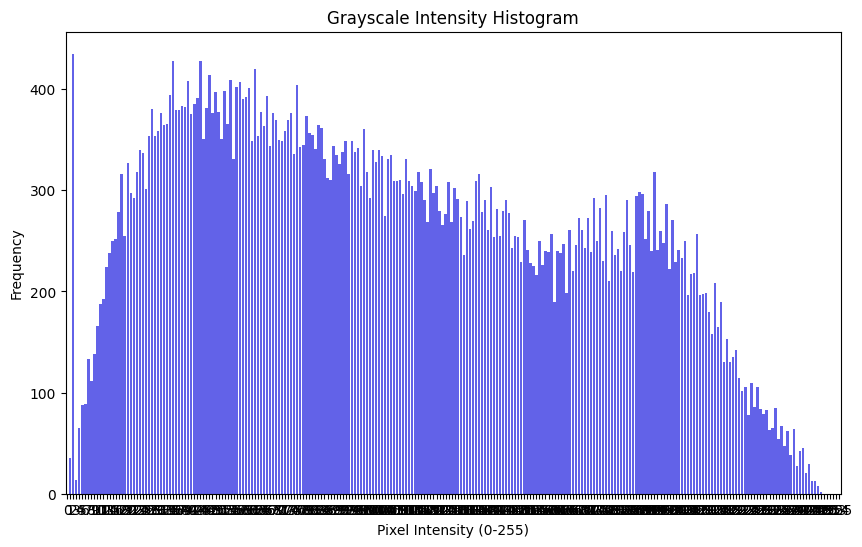

In [39]:
# Visualize the grayscale histogram
plt.figure(figsize=(10, 6))
sns.barplot(x=np.arange(256), y=features["histogram"], color="blue", alpha=0.7)
plt.title("Grayscale Intensity Histogram")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.show()

In [27]:
# Print extracted features
print("\n### Extracted Features ###")
print(f"Contrast (Texture): {features['contrast']:.4f}")
print(f"Energy (Texture): {features['energy']:.4f}")
print(f"Area (Shape): {features['area']:.2f}")
print(f"Perimeter (Shape): {features['perimeter']:.2f}")
print(f"Aspect Ratio (Shape): {features['aspect_ratio']:.2f}")


### Extracted Features ###
Contrast (Texture): 6.5521
Energy (Texture): 0.9693
Area (Shape): 65025.00
Perimeter (Shape): 1020.00
Aspect Ratio (Shape): 1.00
